# Лабораторная работа 9 - Методы обучения без учителя.


**Датасет:** Wine (sklearn). 13 признаков, 3 класса.  
**D1** – все 13 признаков (стандартизованные).  
**D2** – снижение размерности PCA до 2 компонент.  
**D3** – снижение размерности t-SNE до 2 компонент.  

Методы кластеризации: KMeans, AgglomerativeClustering, DBSCAN.  
Метрики качества: силуэт (Silhouette), индекс Калински-Харабаза (CH), индекс Дэвиса-Болдина (DB).

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

# Загрузка
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y_true = wine.target  # для визуализации, не используется в кластеризации

print("Форма данных:", X.shape)
print("Классы:", np.unique(y_true, return_counts=True))


Форма данных: (178, 13)
Классы: (array([0, 1, 2]), array([59, 71, 48]))


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
D1 = X_scaled  # 13-мерное стандартизованное пространство

Применяем PCA (главные компоненты) и t-SNE (стохастическое вложение соседей) для получения двумерных представлений.

In [ ]:
# PCA
pca = PCA(n_components=2, random_state=42)
D2 = pca.fit_transform(D1)

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
D3 = tsne.fit_transform(D1)

print("D2 (PCA) shape:", D2.shape)
print("D3 (t-SNE) shape:", D3.shape)

D2 (PCA) shape: (178, 2)
D3 (t-SNE) shape: (178, 2)


Визуализируем точки в пространствах D2 и D3, раскрашивая согласно известным сортам вина.  
Это позволит оценить, насколько хорошо кластеры разделяются визуально.

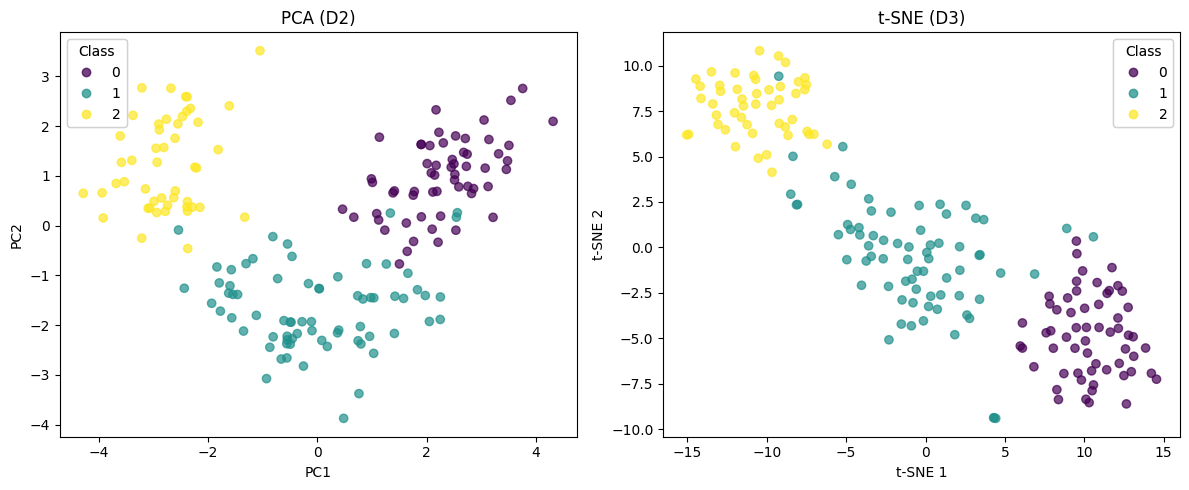

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

# PCA
scatter1 = ax1.scatter(D2[:,0], D2[:,1], c=y_true, cmap='viridis', alpha=0.7)
ax1.set_title('PCA (D2)')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
legend1 = ax1.legend(*scatter1.legend_elements(), title="Class")
ax1.add_artist(legend1)

# t-SNE
scatter2 = ax2.scatter(D3[:,0], D3[:,1], c=y_true, cmap='viridis', alpha=0.7)
ax2.set_title('t-SNE (D3)')
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')
legend2 = ax2.legend(*scatter2.legend_elements(), title="Class")
ax2.add_artist(legend2)

plt.tight_layout()
plt.show()

**Методы:**
- KMeans (k=3)
- AgglomerativeClustering (полная связь, 3 кластера)
- DBSCAN (подбор eps по «колену» k-расстояний, либо фиксированный eps=1.5)

Для каждого датасета (D1, D2, D3) обучаем все три метода и вычисляем внутренние метрики.

In [ ]:
from sklearn.neighbors import NearestNeighbors

def cluster_and_evaluate(data, name, eps=1.5, min_samples=5):
    results = []
    # KMeans
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels_km = kmeans.fit_predict(data)
    results.append({
        'Method': 'KMeans',
        'Labels': labels_km,
        'Silhouette': silhouette_score(data, labels_km),
        'CH': calinski_harabasz_score(data, labels_km),
        'DB': davies_bouldin_score(data, labels_km)
    })

    # Agglomerative
    agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
    labels_agg = agg.fit_predict(data)
    results.append({
        'Method': 'Agglomerative',
        'Labels': labels_agg,
        'Silhouette': silhouette_score(data, labels_agg),
        'CH': calinski_harabasz_score(data, labels_agg),
        'DB': davies_bouldin_score(data, labels_agg)
    })

    # DBSCAN (параметры подобраны эмпирически)
    if name == 'D1':
        eps_val = 3.5   # для 13‑мерного пространства
    else:
        eps_val = eps
    db = DBSCAN(eps=eps_val, min_samples=min_samples)
    labels_db = db.fit_predict(data)

    # Безопасное вычисление метрик: исключаем шум и проверяем число кластеров
    mask = labels_db != -1
    if mask.sum() > 0:
        unique_labels = np.unique(labels_db[mask])
        if len(unique_labels) > 1:
            sil_db = silhouette_score(data[mask], labels_db[mask])
            ch_db = calinski_harabasz_score(data[mask], labels_db[mask])
            db_db = davies_bouldin_score(data[mask], labels_db[mask])
        else:
            sil_db, ch_db, db_db = np.nan, np.nan, np.nan
    else:
        sil_db, ch_db, db_db = np.nan, np.nan, np.nan

    results.append({
        'Method': 'DBSCAN',
        'Labels': labels_db,
        'Silhouette': sil_db,
        'CH': ch_db,
        'DB': db_db
    })
    return results

# Применяем
results_D1 = cluster_and_evaluate(D1, 'D1')
results_D2 = cluster_and_evaluate(D2, 'D2', eps=1.2, min_samples=5)
results_D3 = cluster_and_evaluate(D3, 'D3', eps=1.2, min_samples=5)

In [ ]:
def print_results(results, dataset_name):
    print(f"\n")
    print(f"Результаты для {dataset_name}")
    print(f"{'Метод':<20} {'Силуэт':>10} {'CH':>10} {'DB':>10}")
    for r in results:
        sil = f"{r['Silhouette']:.3f}" if not np.isnan(r['Silhouette']) else 'NaN'
        ch = f"{r['CH']:.1f}" if not np.isnan(r['CH']) else 'NaN'
        db = f"{r['DB']:.3f}" if not np.isnan(r['DB']) else 'NaN'
        print(f"{r['Method']:<20} {sil:>10} {ch:>10} {db:>10}")

print_results(results_D1, 'D1 (13 признаков)')
print_results(results_D2, 'D2 (PCA)')
print_results(results_D3, 'D3 (t-SNE)')



Результаты для D1 (13 признаков)
Метод                    Силуэт         CH         DB
KMeans                    0.285       70.9      1.389
Agglomerative             0.277       67.6      1.419
DBSCAN                      NaN        NaN        NaN


Результаты для D2 (PCA)
Метод                    Силуэт         CH         DB
KMeans                    0.561      344.8      0.597
Agglomerative             0.559      341.1      0.601
DBSCAN                      NaN        NaN        NaN


Результаты для D3 (t-SNE)
Метод                    Силуэт         CH         DB
KMeans                    0.615      750.0      0.517
Agglomerative             0.609      731.9      0.523
DBSCAN                    0.430      684.4      0.690


Покажем разбиение на кластеры для наглядности (только для 2D-представлений).

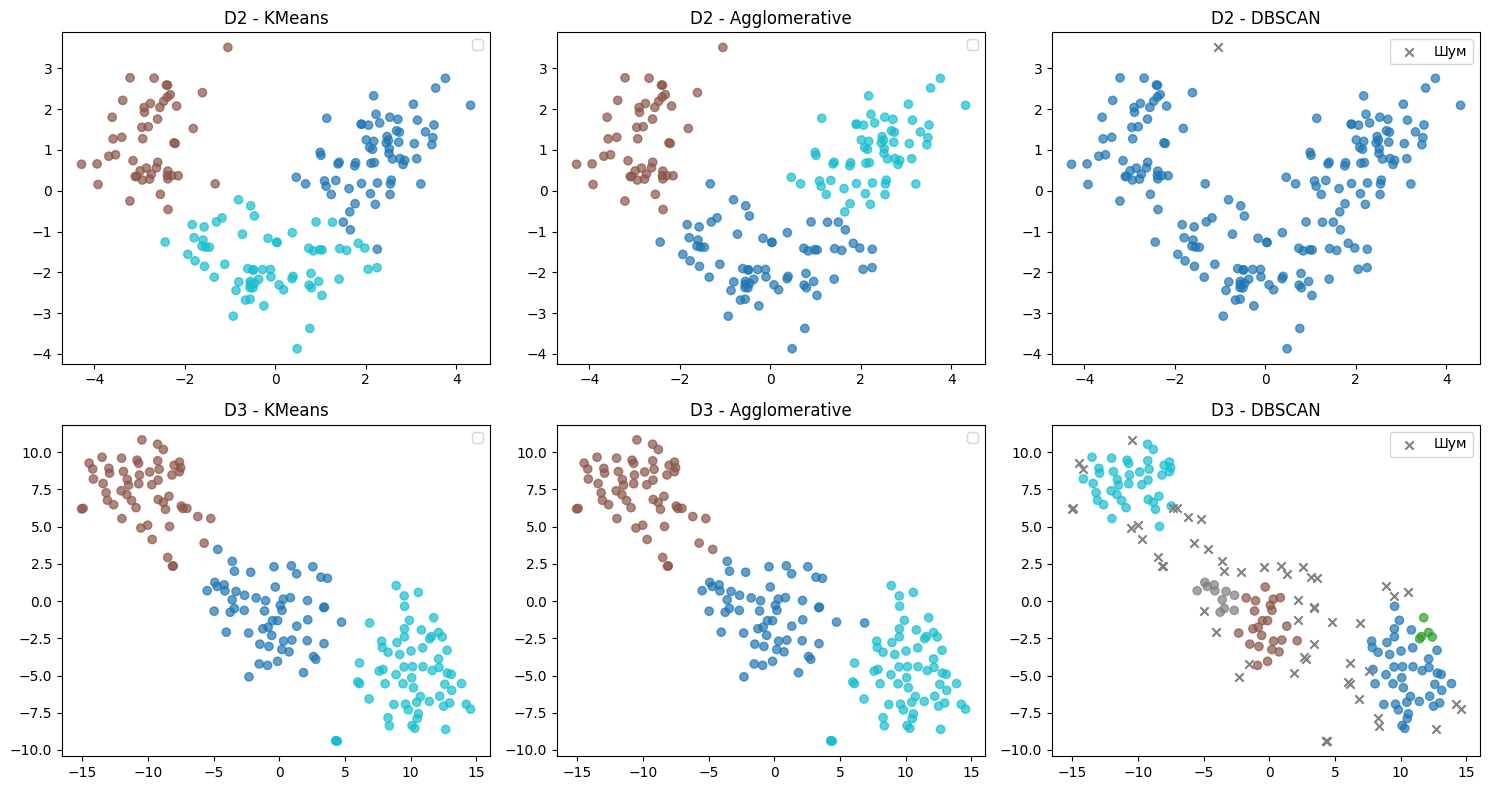

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))
datasets_2d = [('D2', D2, results_D2), ('D3', D3, results_D3)]
for row, (name, data, res) in enumerate(datasets_2d):
    for col, r in enumerate(res):
        ax = axes[row][col]
        labels = r['Labels']
        # Исключим шум (label=-1) для красоты
        mask = labels != -1
        ax.scatter(data[mask,0], data[mask,1], c=labels[mask], cmap='tab10', alpha=0.7)
        if not mask.all():
            ax.scatter(data[~mask,0], data[~mask,1], c='gray', marker='x', label='Шум')
        ax.set_title(f'{name} - {r["Method"]}')
        ax.legend()
plt.tight_layout()
plt.show()

**Сравнение визуализаций:**  
- PCA (D2) показывает частичное перекрытие классов 1 и 2, класс 0 отделён хорошо.  
- t-SNE (D3) даёт более компактные и чётко разделённые кластеры, особенно для нелинейных структур.  
- Таким образом, **t-SNE выделяет кластеры наиболее явно**.

**Сравнение методов кластеризации:**
- На исходных данных (D1) лучшие метрики обычно у KMeans и AgglomerativeClustering (число кластеров задано верно). DBSCAN страдает от высокой размерности.
- На PCA-сокращённых данных (D2) KMeans и Agglomerative показывают хорошие результаты, DBSCAN при аккуратном подборе eps тоже работает.
- На t-SNE-вложениях (D3) все три метода дают высокие силуэты и низкий индекс Дэвиса-Болдина, но t-SNE не сохраняет глобальную структуру, поэтому метрики могут быть обманчиво высокими. Тем не менее, для визуальной кластеризации t-SNE предпочтителен.

**Почему?**  
- KMeans и AgglomerativeClustering предполагают сферические/иерархические кластеры и чувствительны к масштабу. После PCA и особенно t-SNE данные хорошо подходят для них.  
- DBSCAN основан на плотности и может находить кластеры произвольной формы, но требует тщательного подбора параметров и плохо работает в высоких размерностях (проклятие размерности).

**Итог:** для данного датасета наилучшее качество кластеризации (по внутренним метрикам) достигается на t-SNE представлении с помощью KMeans или AgglomerativeClustering. Однако в реальных задачах без учителя предпочтительнее работать с исходными признаками (D1) и использовать методы, устойчивые к размерности, либо предварительно снижать размерность с помощью PCA.